# Importing Libraries

In [2]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt
import os
import piexif
import math
from math import sin, cos, sqrt, atan2, radians

# Loading All Images from a folder

In [3]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        images.append(filename)
    return images

# Entering File Location

In [4]:
filename=load_images_from_folder("C:\\Users\\Rohit\Documents\Mega Project\Simulation\mumbai flood/")

# Converting decimal degrees to degree, minute, second

In [5]:
def decdeg2dms(dd):
    mnt,sec = divmod(dd*3600,60)
    deg,mnt = divmod(mnt,60)
    return deg,mnt,sec

In [6]:
#List of cluster centers in chennai
centerlat=[13.1187,13.0764,13.0086,12.8389,12.932294,13.001666]
centerlon=[80.2622,80.2073,80.2186,80.2165,80.182318, 80.137055]

In [7]:
#List of cluster centers in mumbai
centerlat=[19.2313,18.9652,19.2380,19.0058,19.1849,19.1159,19.0600,19.1166,19.1628,19.2168,19.1369]
centerlon=[72.7945,72.8219,72.8531,72.8439,72.8494,72.8510,72.8966,72.9103,72.9502,72.9790,72.8314]

# (First Method) Function to calculate distance between two coordinates

In [9]:
def distance(originlat,originlon,destlat,destlon):
    from math import sin, cos, sqrt, atan2, radians
    lat=[0,0]
    lon=[0,0]
    R=6373.0
    lat[0]=radians(originlat)
    lon[0]=radians(originlon)
    lat[1]=radians(destlat)
    lon[1]=radians(destlon)
    dlon=lon[1]-lon[0]
    dlat=lat[1]-lat[0]
    a= sin(dlat/ 2)**2 + cos(lat[0]) * cos(lat[1]) * sin(dlon/ 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
  #  print(originlat,",",originlon,",",destlat,",",destlon)
    distance = R * c
    return distance

# Method 1: Generating random coordinates within a rectangular boundary and selecting the point if it is within 2 Km radius 

In [132]:
destlat=0
destlon=0
index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "mumbai flood"
dest = "test_mumbai_1"

for i in range(len(centerlat)):
    
    if(i==len(centerlat)-1):
        cluster_size=val
        
        
    if(val>0):       
        cluster_size=random.randrange(20,50,1) #Having a cluster size within 30 to 80
    
    val = val-cluster_size 
    
    cluster.append(cluster_size)
        
    for j in range(cluster_size): 
        try:
            img = Image.open(source + "/"+filename[index])
            img=img.convert('RGB')
            while(1):
                destlat=random.randrange(188927,193032,33) #manually enter the latitude*10000 range and the steps
                destlon=random.randrange(727799,730118,18) #manually enter the longitude*10000 range and the steps
                x=distance(centerlat[i],centerlon[i],destlat/10000,destlon/10000)
                
                if(x<2): #If distance is <2 Km, we break out of the infinite loop
                    break                
            
            #Converting decimal degree to degree, minute, second
            deglat,mntlat,seclat=decdeg2dms(destlat/10000)
            deglon,mntlon,seclon=decdeg2dms(destlon/10000)
            
            #Preparing the structure of coordinate data
            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            
            #print(filename[index])
            
            #Save image in desxtination folder
            img.save(dest + "/" + filename[index], exif=exif_bytes)
            index=index+1
            
        except:
            index=index+1
            continue

In [133]:
cluster #No. of points in each cluster

[36, 36, 30, 43, 44, 26, 26, 47, 49, 39, 39]

# Method 2: Generating random coordinates from a normal multivariate distribution within a rectangular boundary and selecting a point within it

In [151]:
destlat=0
destlon=0

index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "mumbai flood"
dest = "test_mumbai_2"

for i in range(len(centerlat)):
    
    if(i==len(centerlat)-1):
        cluster_size=val
    
    if(val>0):       
        cluster_size=random.randrange(20,50,1)
        
    val = val-cluster_size
            
    cluster.append(cluster_size)
    
    x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]],cluster_size).T
    
    x=(x-min(x))/(max(x)-min(x)) #Normalization
    y=(y-min(y))/(max(y)-min(y)) #Normalization
    
    x=centerlat[i]-0.02+0.04*x #Going 2km down and multiplying 4km with a value picked from a normal distribution
    y=centerlon[i]-0.02+0.04*y #Going 2km left and multiplying 4km with a value picked from a normal distribution
    
    for j in range(cluster_size):
        try:
            
            img = Image.open(source + "/" + filename[index])
            
            img=img.convert('RGB')
            
            deglat,mntlat,seclat=decdeg2dms(x[j])
            deglon,mntlon,seclon=decdeg2dms(y[j])
            

            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            
            #print(filename[index])
            
            img.save(dest + "/" + filename[index], exif=exif_bytes)
            index=index+1
            
        except:
            index=index+1
            continue

In [152]:
cluster #No. of points in each cluster

[41, 26, 30, 23, 20, 47, 43, 37, 28, 32, 35]

# Extracting Geolocation Data From Images

In [122]:
class ImageMetaData(object):
    exif_data = None
    image = None

    def __init__(self, img_path):
        self.image = Image.open(img_path)
        #print(self.image._getexif())
        self.get_exif_data()
        super(ImageMetaData, self).__init__()

    def get_exif_data(self):
        """Returns a dictionary from the exif data of an PIL Image item. Also converts the GPS Tags"""
        exif_data = {}
        info = self.image._getexif()
        if info:
            for tag, value in info.items():
                decoded = TAGS.get(tag, tag)
                if decoded == "GPSInfo":
                    gps_data = {}
                    for t in value:
                        sub_decoded = GPSTAGS.get(t, t)
                        gps_data[sub_decoded] = value[t]

                    exif_data[decoded] = gps_data
                else:
                    exif_data[decoded] = value
                    
        self.exif_data = exif_data
        return exif_data

    def get_if_exist(self, data, key):
        if key in data:
            return data[key]
        return None

    def convert_to_degress(self, value):

        """Helper function to convert the GPS coordinates 
        stored in the EXIF to degress in float format"""
        d0 = value[0]
        d = float(d0)

        m0 = value[1]
        m = float(m0)

        s0 = value[2]
        s = float(s0)

        return d + (m / 60.0) + (s / 3600.0)

    def get_lat_lng(self):
        """Returns the latitude and longitude, if available, from the provided exif_data (obtained through get_exif_data above)"""
        lat = None
        lng = None
        exif_data = self.get_exif_data()
        if "GPSInfo" in exif_data:      
            gps_info = exif_data["GPSInfo"]
            gps_latitude = self.get_if_exist(gps_info, "GPSLatitude")
            gps_latitude_ref = self.get_if_exist(gps_info, 'GPSLatitudeRef')
            gps_longitude = self.get_if_exist(gps_info, 'GPSLongitude')
            gps_longitude_ref = self.get_if_exist(gps_info, 'GPSLongitudeRef')
            if gps_latitude and gps_longitude:
                lat = self.convert_to_degress(gps_latitude)
                lng = self.convert_to_degress(gps_longitude)
        return lat, lng

# Reading file having images with simulated locations

In [147]:
source = "test_mumbai_1"
filename=load_images_from_folder(source + "/")

# Getting latitude and longitude of images

In [148]:
lat =[]
lng = []
for i in range(len(filename)):
    path_name = source + "/" + filename[i]
    meta_data =  ImageMetaData(path_name)
    x, y= meta_data.get_lat_lng()
    lat.append(x)
    lng.append(y)

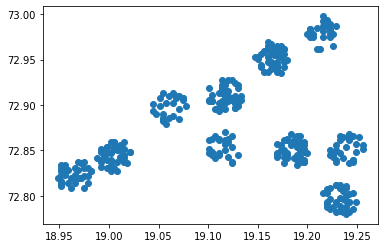

In [149]:
plt.scatter(lat,lng)

# (Second Method) Suggested by Ashish Sir

In [142]:
#Chennai
# Anna arch Arumbakkam, thayapa, Varathammal Garden 3rd St(TNHB Colony Purasaiwakkam), Natesa nagar, perambur, tondiarpet, Joseph Hospitals (near kilpauk ektu upore), The Madras Medical Mission Hospital, Government Peripheral Hospital (Anna Nagar), Ganapathy Colony
centres=[[13.0765, 80.2179],[13.1023, 80.2847],[13.093221, 80.247043],[13.0586, 80.1938],[13.1210, 80.2326],[13.1261, 80.2880],[13.075537, 80.234037],[13.0861, 80.1874],[13.0955, 80.2193],[13.0512, 80.2607]]
sd2=[0.0025,0.0015,0.0035,0.0045,0.0045,0.0035,0.0015,0.0035,0.0025,0.0055]

#Chennai
rectangle_leftcorner=[[13.018443,80.144705],[13.026470, 80.280661],[13.072124,80.290445],[13.11108, 80.295252]]
rectangle_rightcorner=[[13.069950, 80.108313],[13.069950,80.152601],[13.111416,80.150026],[13.132480, 80.192255]]

val=494 # Total images in the folder

source = "C:\\Users\Rohit\Documents\Mega Project\Simulation\chennai flood"
dest = "C:\\Users\Rohit\Documents\Mega Project\Simulation\chennai flood_new_method"

In [175]:
#Mumbai
# Dadar, Chembur, Andheri, Malad, Borivali, Thane, Navi Mumbai, Dombivli, Airoli, Bhiwandi
centres=[[19.018619455632507, 72.84583975582304],[19.056104997428307, 72.89867796082896],[19.11515500727002, 72.86159910201802],[19.18650598870332, 72.84546293172963],[19.235784983743407, 72.85610593791993],[19.204663125982744, 72.97832884171184],[19.037931530246006, 73.03154386602067],[19.22250408001917, 73.09666938248976],[19.157979306713013, 72.99607581304869],[19.286031363159147, 73.0496341635841]]
sd2=[0.0025,0.0015,0.0035,0.0045,0.0045,0.0035,0.0015,0.0035,0.0025,0.0055]

#Mumbai
rectangle_leftcorner=[[18.9751198210964, 72.81425406399514],[19.07833175002693, 72.82867362706747],[19.14191465609462, 72.81631400728575],[19.305949011151974, 72.86712577646665]]
rectangle_rightcorner=[[18.966678277307473, 72.83965994974312],[19.040689545921005, 72.91862418595524],[19.004337248616135, 73.14453056974347],[19.371387246975214, 73.10951164197097]]

val=494 # Total images in the folder

source = "C:\\Users\Rohit\Documents\Mega Project\Simulation\mumbai flood"
dest = "C:\\Users\Rohit\Documents\Mega Project\Simulation\mumbai flood_new_method"

In [144]:
data=[]

for i in range(10):
    src=centres[i]
    r=sd2[i]

    np.random.seed(i)

    no=13+6*i #13 constant, 6 variable
    
    value1 = np.random.normal(src[0],r,no)
    value2 = np.random.normal(src[1],r,no)
    
    for j in range(no):
        x_cord=value1[j]
        y_cord=value2[j]
        
        data.append([x_cord,y_cord])

In [145]:
np.random.seed(17)

no=[20,30,20,30] #Total random points = 100

for i in range(len(no)):
    lng_rand=np.random.rand(no[i])
    lat_rand=np.random.rand(no[i])
    k=0

    lng_min=min(rectangle_leftcorner[i][1],rectangle_rightcorner[i][1])
    lng_max=max(rectangle_leftcorner[i][1],rectangle_rightcorner[i][1])
    lat_min=min(rectangle_leftcorner[i][0],rectangle_rightcorner[i][0])
    lat_max=max(rectangle_leftcorner[i][0],rectangle_rightcorner[i][0])

    for j in range(no[i]):
        x_cord=lat_min+lat_rand[j]*(lat_max-lat_min)
        y_cord=lng_min+lng_rand[j]*(lng_max-lng_min)
        data.append([x_cord,y_cord])

In [170]:
df=pd.DataFrame(data,columns=['lat','lng'])

In [172]:
df.to_excel("output.xlsx")

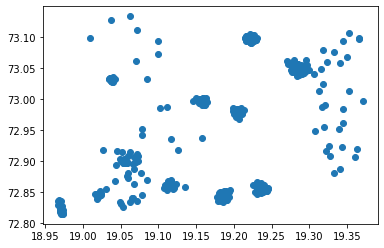

In [173]:
plt.scatter(df.loc[:,"lat"],df.loc[:,"lng"])

In [176]:
destlat=0
destlon=0
index=0
cluster_size=0
cluster=[]

In [178]:
index=0
for i in range(len(df)):
    try:
        img = Image.open(source + "/" + filename[index])

        img=img.convert('RGB')

        deglat,mntlat,seclat=decdeg2dms(df["lat"][i])
        deglon,mntlon,seclon=decdeg2dms(df["lng"][i])
    

        gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
               piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
               piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
               piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
               }
        exif_dict = {"GPS":gps_ifd}
        exif_bytes = piexif.dump(exif_dict)

        print(filename[index])

        img.save(dest + "/" + filename[index], exif=exif_bytes)
        index=index+1

    except Exception as e:
        print(e)
        index=index+1
        continue

mumbai flood_10.jpg
mumbai flood_100.jpg
mumbai flood_101.jpg
mumbai flood_102.jpg
mumbai flood_103.jpg
mumbai flood_104.jpg
mumbai flood_105.jpg
mumbai flood_106.jpg
mumbai flood_108.jpg
mumbai flood_109.jpg
mumbai flood_11.jpg
mumbai flood_110.jpg
mumbai flood_111.jpg
mumbai flood_112.jpg
mumbai flood_113.jpg
mumbai flood_115.jpg
mumbai flood_116.jpg
mumbai flood_117.jpg
mumbai flood_118.jpg
mumbai flood_119.jpg
mumbai flood_12.jpg
mumbai flood_120.jpg
mumbai flood_121.jpg
mumbai flood_122.jpg
mumbai flood_123.jpg
mumbai flood_125.jpg
mumbai flood_126.jpg
mumbai flood_127.jpg
mumbai flood_128.jpeg
mumbai flood_129.jpg
mumbai flood_13.jpg
mumbai flood_130.jpg
mumbai flood_131.jpg
mumbai flood_132.jpg
mumbai flood_134.jpg
mumbai flood_135.jpg
mumbai flood_136.jpg
mumbai flood_137.jpeg
mumbai flood_138.jpg
mumbai flood_139.jpg
mumbai flood_14.jpg
mumbai flood_140.jpg
mumbai flood_141.jpg
mumbai flood_142.jpg
mumbai flood_143.jpg
mumbai flood_144.jpg
mumbai flood_145.jpg
mumbai flood_146

mumbai flood_497.jpg
mumbai flood_499.jpg
mumbai flood_5.jpg
mumbai flood_50.jpg
mumbai flood_500.jpg
mumbai flood_501.jpg
mumbai flood_502.jpg
mumbai flood_503.jpg
mumbai flood_504.jpeg
mumbai flood_506.jpg
mumbai flood_507.jpg
mumbai flood_508.jpg
mumbai flood_509.jpg
mumbai flood_51.jpg
mumbai flood_511.jpg
mumbai flood_513.jpg
mumbai flood_514.jpg
mumbai flood_515.jpg
mumbai flood_516.jpg
mumbai flood_517.jpg
mumbai flood_518.jpg
mumbai flood_519.jpg
mumbai flood_52.jpeg
mumbai flood_520.jpg
mumbai flood_521.jpg
mumbai flood_523.jpg
mumbai flood_524.jpg
mumbai flood_525.jpg
mumbai flood_526.jpg
mumbai flood_527.jpg
mumbai flood_528.jpg
mumbai flood_529.jpg
mumbai flood_53.jpg
mumbai flood_530.jpeg
mumbai flood_531.jpg
mumbai flood_532.jpeg
mumbai flood_533.jpg
mumbai flood_534.jpg
mumbai flood_535.jpg
mumbai flood_536.jpg
mumbai flood_537.jpg
mumbai flood_538.jpg
mumbai flood_539.jpg
mumbai flood_54.jpg
mumbai flood_540.jpg
mumbai flood_541.jpg
mumbai flood_543.jpg
mumbai flood_544

In [13]:
df["lat"][0]

13.076804187541232